In [ ]:
import numpy as np
import pandas
import matplotlib.pyplot as plt
import glob

: 

### Figure 4A

In [ ]:
benchmark = pandas.read_csv('data/benchmarking.csv')
benchmark = benchmark.loc[benchmark["stride"] < 200]
# arrange frames in ascending order
benchmark = benchmark.sort_values(by="frames")
benchmark['frames'] = benchmark['frames'].astype(str)
plt.bar(
    benchmark["frames"],
    benchmark["time_seconds"],
    color="#34baeb")

plt.xlabel("Number of Sampled Frames")
plt.ylabel("Runtime (seconds)")
# transparent background save
plt.gcf().patch.set_alpha(0.0)
plt.gca().patch.set_alpha(0.0)
plt.savefig("benchmarking.png", dpi=500)

: 

### Figure 4B

In [ ]:
filetimes = pandas.read_csv('data/filetimes.txt')
# arrange frames in ascending order
filetimes = filetimes.sort_values(by="lines")
filetimes['lines'] = filetimes['lines'].astype(str)

plt.bar(
    filetimes["lines"],
    filetimes["time_seconds"],
    color="#34baeb")

plt.xlabel("Number of Trajectory Files")
plt.ylabel("Time (seconds)")

: 

### Figure 4C

In [ ]:
### Scatterplot code here and cgk file is figures/data

# load cgk.dat file
cgk = np.loadtxt('./data/cgkfiles/cgk.dat')
x0 = cgk[:, 3]  # Equilibrium bond distance (Å)
k = cgk[:, 2]   # Spring constant

# create figure in publication format
plt.figure(figsize=(4,3))
plt.scatter(k, x0, color='black', s=10)

plt.xlabel(r'Equilibrium Distance $x_0$ (Å)', fontsize=8)
plt.ylabel(r'Spring Constant $k$ (kcal/mol Å$^2$)', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# plt.savefig('Fig4C.png', format='png')

: 

### Figure 4D

In [18]:
# Get files sorted (starting from 1)
files = sorted(glob.glob('./data/cgkfiles/cgk_*.dat'), key=lambda x: int(x.split('_')[-1].split('.')[0]))

# Read each into a dict
data_per_file = {}

for file in files:
    df = pd.read_csv(file, sep='\s+', header=None, names=['atom1', 'atom2', 'distance', 'coeff'])
    data_per_file[file] = df


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/8v/2qv8nj450nzdjyyvwvl3vsr40000gn/T/ipykernel_5350/1488743149.py:8: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file, sep='\s+', header=None, names=['atom1', 'atom2', 'distance', 'coeff'])


In [ ]:
files = sorted(glob.glob('data/cgkfiles/cgk_*.dat'), key=lambda x: int(x.split('_')[-1].split('.')[0]))

# Read each into a dict
data_per_file = {}

for file in files:
    df = pd.read_csv(file, sep='\s+', header=None, names=['atom1', 'atom2', 'distance', 'coeff'])
    data_per_file[file] = df
len(files)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/8v/2qv8nj450nzdjyyvwvl3vsr40000gn/T/ipykernel_5350/2647013926.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file, sep='\s+', header=None, names=['atom1', 'atom2', 'distance', 'coeff'])


Number of rows: 4, Number of columns: 4


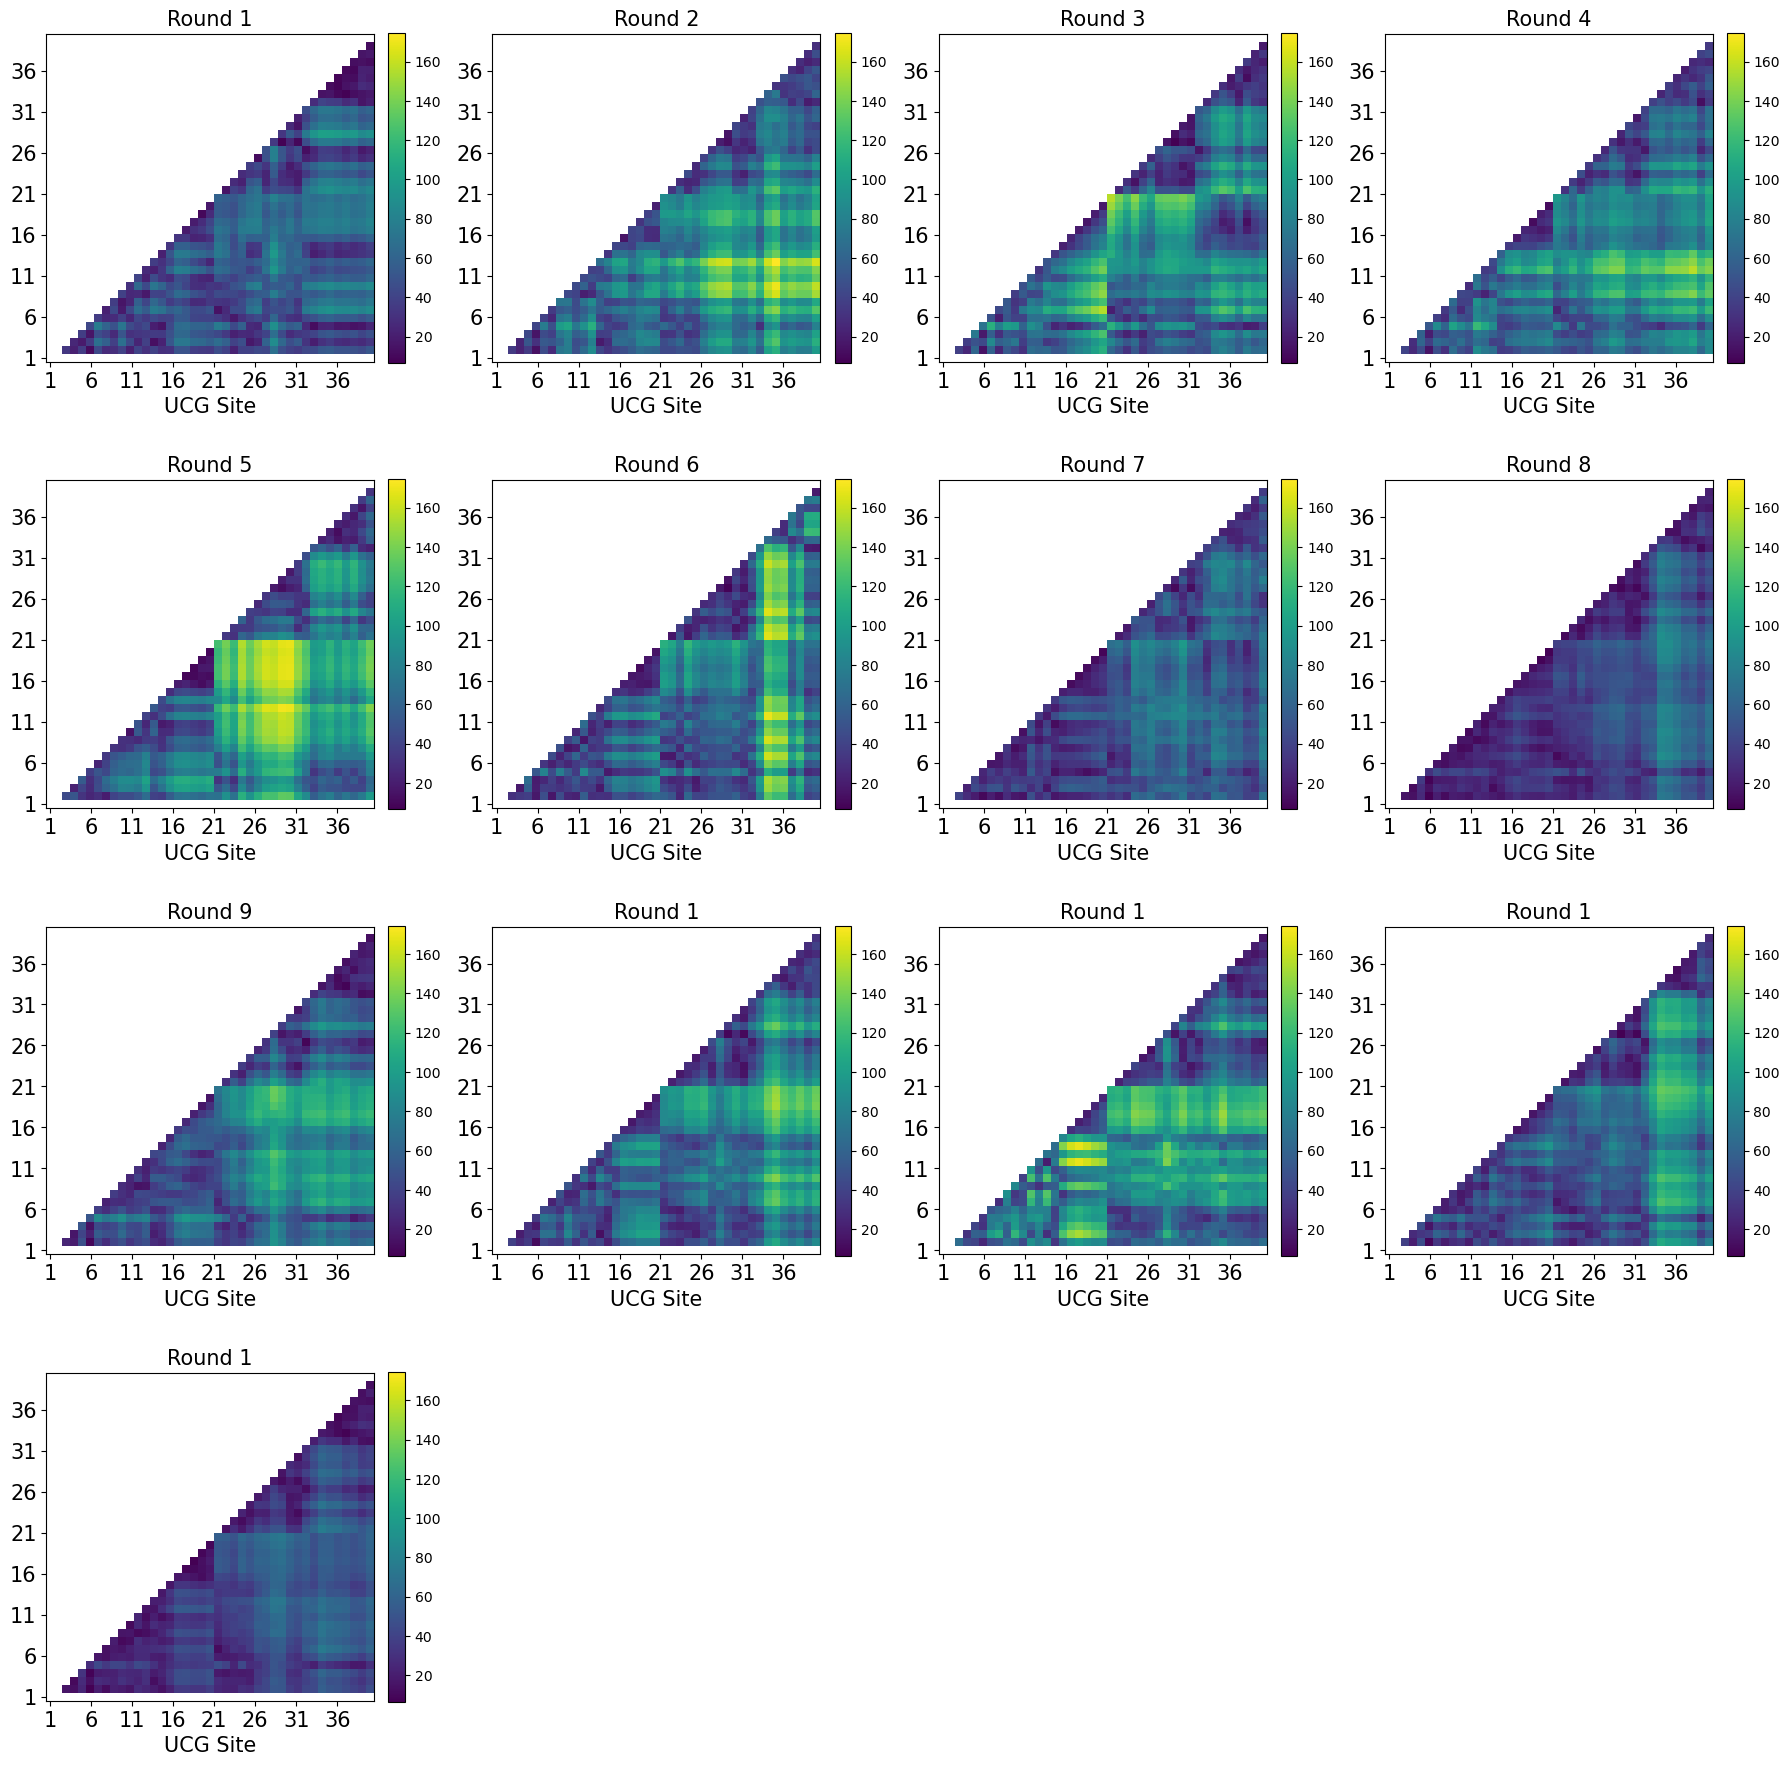

In [25]:
# Step 3: Max atom ID
max_atom = 40

# Step 4: Plot
n_files = len(files)
n_cols = 4
n_rows = (n_files + n_cols - 1) // n_cols
print(f"Number of rows: {n_rows}, Number of columns: {n_cols}")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows))  # Slightly wider for colorbars
axes = axes.flatten()

# Optional: Find common vmin/vmax for all plots (so color scales match)
vmin = pd.concat(data_per_file.values())['distance'].min()
vmax = pd.concat(data_per_file.values())['distance'].max()

for idx, file in enumerate(files):
    ax = axes[idx]
    df = data_per_file[file]
    mat = np.full((max_atom + 1, max_atom + 1), np.nan)

    for _, row in df.iterrows():
        i, j, coeff = int(row['atom1']), int(row['atom2']), row['distance']
        mat[i, j] = coeff

    im = ax.imshow(mat, cmap='viridis', interpolation='none', origin='upper',
                   extent=[0.5, max_atom + 0.5, max_atom + 0.5, 0.5],
                   vmin=vmin, vmax=vmax)

    ax.set_title("Round " + file.split('_')[1][0], fontsize=15)
    ax.set_xlabel('UCG Site', fontsize=15)
    ax.set_xlabel('UCG Site', fontsize=15)
    ax.set_xticks(range(1, max_atom + 1, 5))
    ax.set_yticks(range(1, max_atom + 1, 5))
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.invert_yaxis()

    # Add colorbar next to each plot
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

# Hide any extra subplots
for idx in range(n_files, len(axes)):
    fig.delaxes(axes[idx])

plt.subplots_adjust(wspace=0.5, hspace=0.6)  # More horizontal space for colorbars
plt.tight_layout()
plt.show()
